# STEP 8 — Model Visualization

## Objective

The objective of this step is to visualize machine learning model performance and compare actual population values with predicted values.

### Visualizations

1. Actual vs Predicted Global Population
2. MAE Model Comparison
3. RMSE Model Comparison
4. R² Model Comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
model_results = pd.read_csv(
    "../outputs/tables/model_comparison.csv"
)

prediction_results = pd.read_csv(
    "../outputs/tables/linear_regression_predictions.csv"
)

print("Model Results:")
display(model_results)

print("\nPrediction Results:")
display(prediction_results.head())

Model Results:


,Model,MAE,RMSE,R2
0,Linear Regression,58201.185878,2.303290e+05,0.999997
1,Decision Tree,425897.444995,2.375325e+06,0.999720
2,Random Forest,397226.796641,2.492262e+06,0.999691
3,Gradient Boosting,736436.539373,3.672312e+06,0.999330



Prediction Results:


,Country Name,Country Code,Year,Population,Predicted_Population,Absolute_Error
0,Aruba,ABW,2021,107700.0,109880.435598,2180.435598
1,Aruba,ABW,2022,107310.0,108751.175472,1441.175472
2,Aruba,ABW,2023,107359.0,108900.489999,1541.489999
3,Aruba,ABW,2024,107995.0,109363.903296,1368.903296
4,Aruba,ABW,2025,108785.0,110579.462459,1794.462459


Actual vs Predicted Global Population

In [3]:
global_actual_predicted = (
    prediction_results
    .groupby("Year")[
        ["Population", "Predicted_Population"]
    ]
    .sum()
    .reset_index()
)

global_actual_predicted["Actual_Population_Billions"] = (
    global_actual_predicted["Population"] / 1e9
)

global_actual_predicted["Predicted_Population_Billions"] = (
    global_actual_predicted["Predicted_Population"] / 1e9
)

global_actual_predicted

,Year,Population,Predicted_Population,Actual_Population_Billions,Predicted_Population_Billions
0,2021,7.896080e+09,7.906058e+09,7.896080,7.906058
1,2022,7.965364e+09,7.960354e+09,7.965364,7.960354
2,2023,8.039550e+09,8.034278e+09,8.039550,8.034278
3,2024,8.117485e+09,8.113485e+09,8.117485,8.113485
4,2025,8.192078e+09,8.195073e+09,8.192078,8.195073


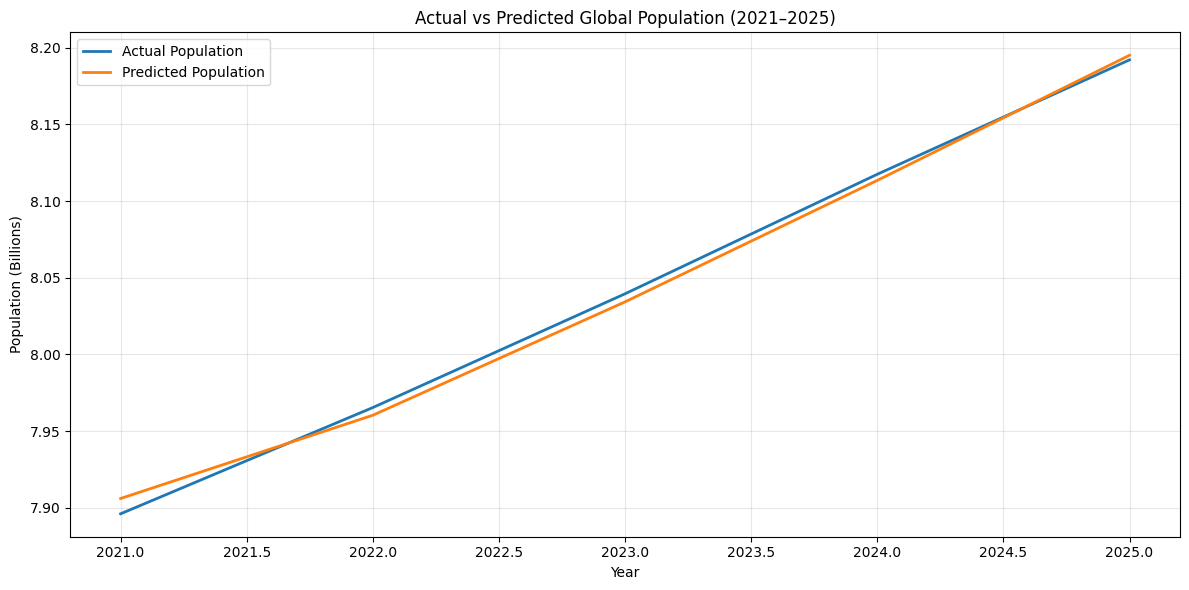

In [4]:
plt.figure(figsize=(12, 6))

plt.plot(
    global_actual_predicted["Year"],
    global_actual_predicted["Actual_Population_Billions"],
    label="Actual Population",
    linewidth=2
)

plt.plot(
    global_actual_predicted["Year"],
    global_actual_predicted["Predicted_Population_Billions"],
    label="Predicted Population",
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Population (Billions)")
plt.title("Actual vs Predicted Global Population (2021–2025)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/actual_vs_predicted_global_population.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

MAE Comparison

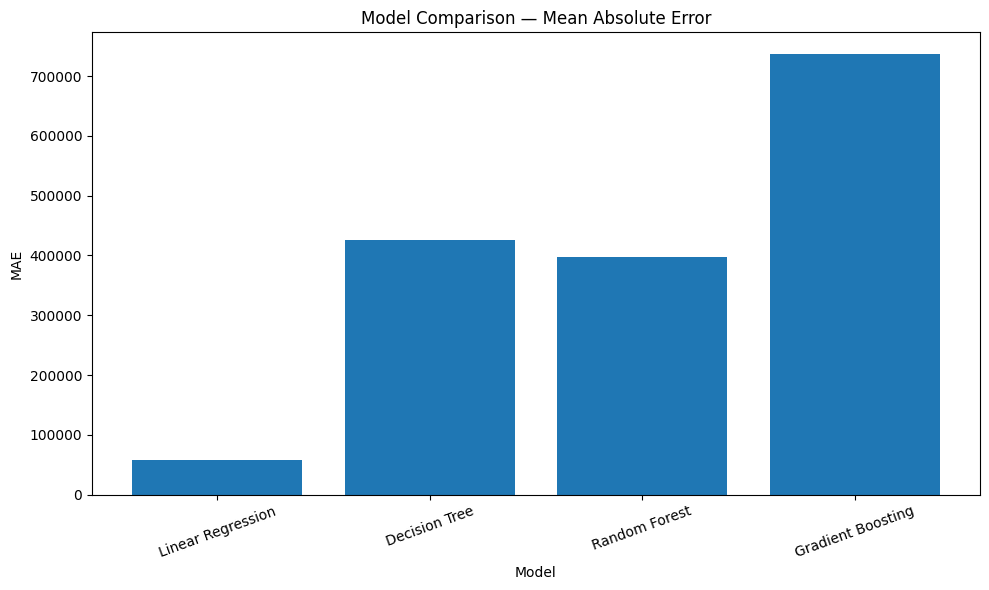

In [5]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_results["Model"],
    model_results["MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Model Comparison — Mean Absolute Error")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/model_comparison_mae.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

RMSE Comparison

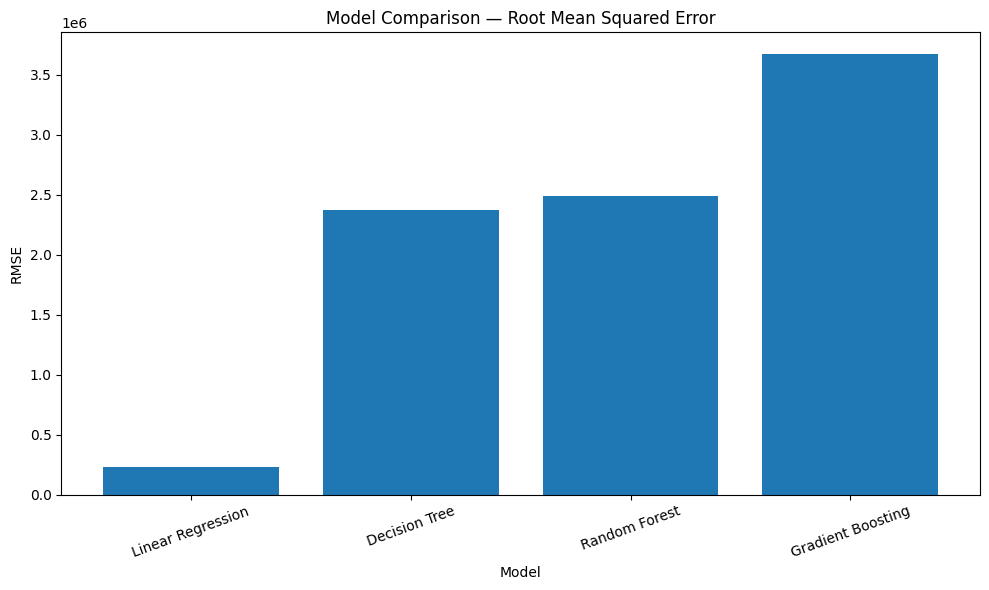

In [6]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_results["Model"],
    model_results["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison — Root Mean Squared Error")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/model_comparison_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

R² Comparison

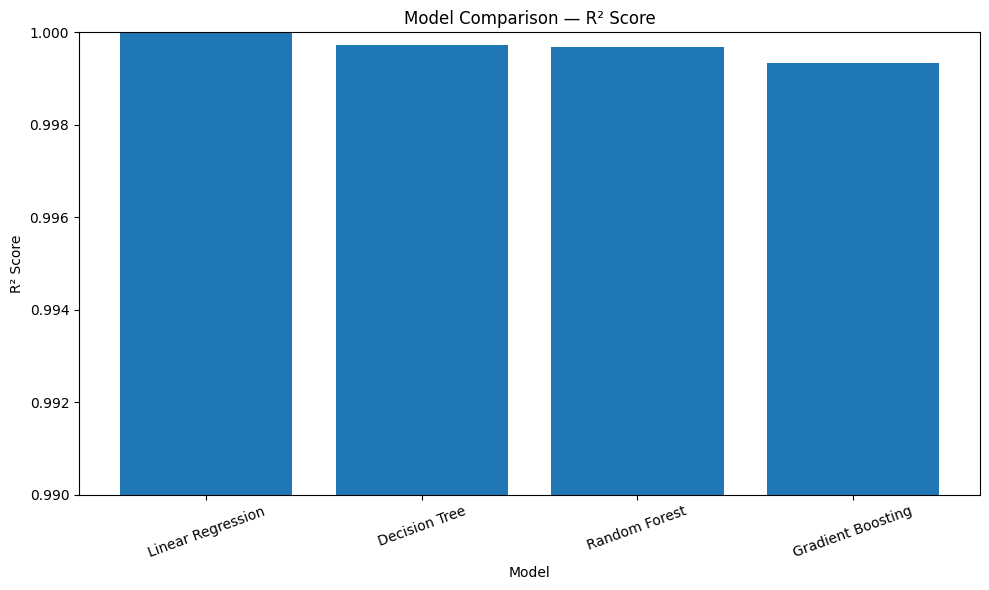

In [7]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_results["Model"],
    model_results["R2"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Comparison — R² Score")

plt.xticks(rotation=20)
plt.ylim(0.99, 1.0)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/model_comparison_r2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Actual vs Predicted Error

In [8]:
global_actual_predicted["Prediction_Error_Billions"] = (
    global_actual_predicted["Actual_Population_Billions"]
    - global_actual_predicted["Predicted_Population_Billions"]
)

global_actual_predicted

,Year,Population,Predicted_Population,Actual_Population_Billions,Predicted_Population_Billions,Prediction_Error_Billions
0,2021,7.896080e+09,7.906058e+09,7.896080,7.906058,-0.009977
1,2022,7.965364e+09,7.960354e+09,7.965364,7.960354,0.005010
2,2023,8.039550e+09,8.034278e+09,8.039550,8.034278,0.005272
3,2024,8.117485e+09,8.113485e+09,8.117485,8.113485,0.003999
4,2025,8.192078e+09,8.195073e+09,8.192078,8.195073,-0.002995


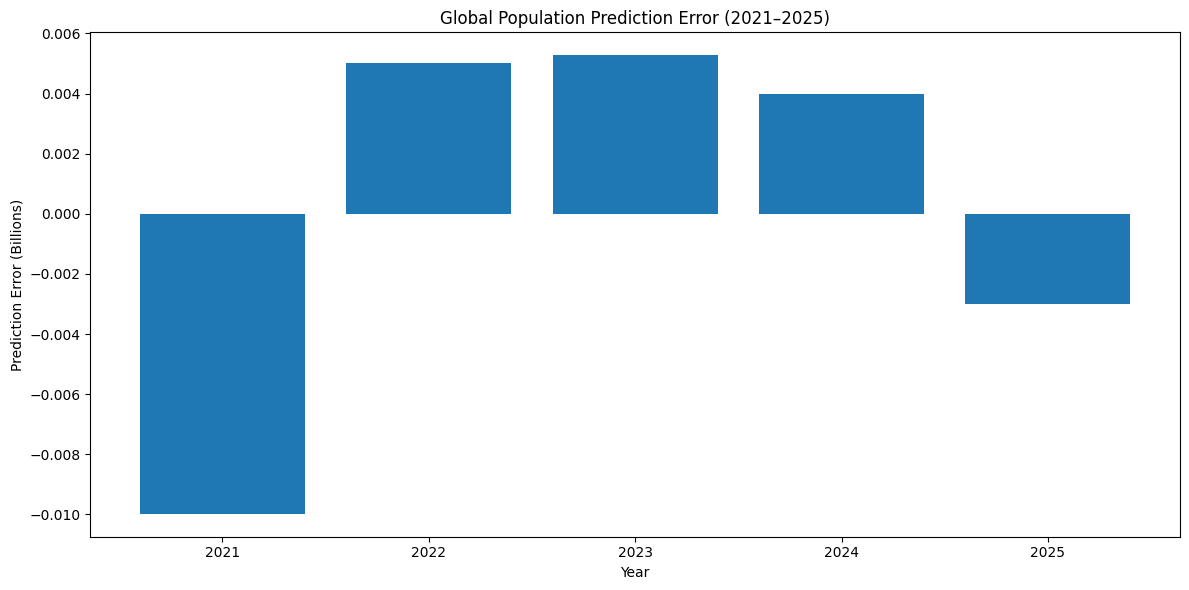

In [9]:
plt.figure(figsize=(12, 6))

plt.bar(
    global_actual_predicted["Year"].astype(str),
    global_actual_predicted["Prediction_Error_Billions"]
)

plt.xlabel("Year")
plt.ylabel("Prediction Error (Billions)")
plt.title("Global Population Prediction Error (2021–2025)")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/global_population_prediction_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()